**24BAD130 Vishal S ML Lab Exp - 10**

**SCENARIO 1 – MATRIX FACTORIZATION USING SVD**

Problem Statement
Use Singular Value Decomposition (SVD) to recommend movies based on latent user-item interactions.

Dataset (Kaggle – Public)
MovieLens Dataset
Dataset Link: https://www.kaggle.com/datasets/grouplens/movielens-100k
(You can pick any dataset if required)

Target Variable: Predicted ratings for unseen movies
Input Feature:
• User ID
• Movie ID
• Ratings

IN-LAB TASKS
1.	Import required Python libraries (NumPy, Pandas, Scikit-learn, Surprise, etc.)
2.	Load the MovieLens dataset
3.	Perform data preprocessing
4.	Create User-Item Interaction Matrix
5.	Normalize the matrix (optional – mean centering)
6.	Apply SVD decomposition
7.	Reduce dimensions (select k latent factors)
8.	Reconstruct the matrix
9.	Predict missing ratings
10.	Generate Top-N recommendations

Evaluation Metrics
• RMSE (Root Mean Square Error)
• MAE (Mean Absolute Error)

Analysis Tasks
• Analyze effect of number of latent factors (k)
• Compare predicted vs actual ratings
• Observe how dimensionality reduction improves performance
• Study overfitting vs underfitting



Visualization
• Heatmap of original vs reconstructed matrix
• Error vs number of latent factors
• Top recommended movies


In [2]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split


In [4]:
# Step 2: Upload ratings.csv and movies.csv

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)



Ratings Shape: (105339, 4)
Movies Shape: (10329, 3)


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [6]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
# Step 3: Data Preprocessing

ratings = ratings[['userId','movieId','rating']]

# Train-Test Split
train_data, test_data = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Train Data Shape:", train_data.shape)
print("Test Data Shape :", test_data.shape)

Train Data Shape: (84271, 3)
Test Data Shape : (21068, 3)


In [8]:
# Step 4: Create User-Item Interaction Matrix

user_item_matrix = train_data.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print("User-Item Matrix Shape:", user_item_matrix.shape)

# Fill missing values
matrix_filled = user_item_matrix.fillna(0)

User-Item Matrix Shape: (668, 9588)


In [9]:
# Step 5: Normalize Matrix

user_means = user_item_matrix.mean(axis=1)

normalized_matrix = user_item_matrix.sub(
    user_means,
    axis=0
).fillna(0)

normalized_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,143882,144656,144976,146344,146656,146684,146878,148238,148626,149532
userId,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0,-0.811321,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.784314,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Step 6 & 7: Apply SVD and Reduce Dimensions

k_values = [5, 10, 20, 50]

rmse_list = []
mae_list = []

for k in k_values:

    print("\nProcessing k =", k)

    svd = TruncatedSVD(
        n_components=k,
        random_state=42
    )

    U = svd.fit_transform(normalized_matrix)

    Sigma = svd.singular_values_

    Vt = svd.components_

    # Step 8: Reconstruct Matrix
    reconstructed = np.dot(
        U,
        np.dot(np.diag(Sigma), Vt)
    )

    reconstructed = reconstructed + \
        user_means.values.reshape(-1, 1)

    reconstructed_df = pd.DataFrame(
        reconstructed,
        index=user_item_matrix.index,
        columns=user_item_matrix.columns
    )

    # Step 9: Predict Ratings
    preds = []
    actuals = []

    for row in test_data.itertuples():

        user = row.userId
        movie = row.movieId

        if user in reconstructed_df.index \
           and movie in reconstructed_df.columns:

            pred = reconstructed_df.loc[user, movie]

            preds.append(pred)

            actuals.append(row.rating)

    # Evaluation Metrics
    rmse = np.sqrt(
        mean_squared_error(actuals, preds)
    )

    mae = mean_absolute_error(
        actuals,
        preds
    )

    rmse_list.append(rmse)
    mae_list.append(mae)

    print("RMSE:", rmse)
    print("MAE :", mae)



Processing k = 5
RMSE: 7.334079243525384
MAE : 3.6388301142735453

Processing k = 10
RMSE: 6.973746425684854
MAE : 3.6734524994306845

Processing k = 20
RMSE: 6.55312856623706
MAE : 3.657081858888277

Processing k = 50
RMSE: 5.6936056424639165
MAE : 3.3677586125503214


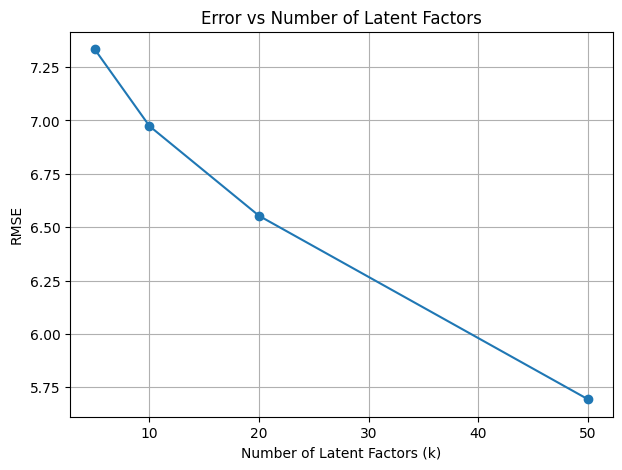

In [15]:
# Visualization: Error vs Number of Latent Factors

plt.figure(figsize=(7,5))

plt.plot(
    k_values,
    rmse_list,
    marker='o'
)

plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Number of Latent Factors")

plt.grid()

plt.show()

In [16]:
# Final Model using Best k

best_k = 50

svd_final = TruncatedSVD(
    n_components=best_k,
    random_state=42
)

U_final = svd_final.fit_transform(
    normalized_matrix
)

Sigma_final = svd_final.singular_values_

Vt_final = svd_final.components_

reconstructed_final = np.dot(
    U_final,
    np.dot(np.diag(Sigma_final), Vt_final)
)

reconstructed_final = reconstructed_final + \
    user_means.values.reshape(-1, 1)

reconstructed_df_final = pd.DataFrame(
    reconstructed_final,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

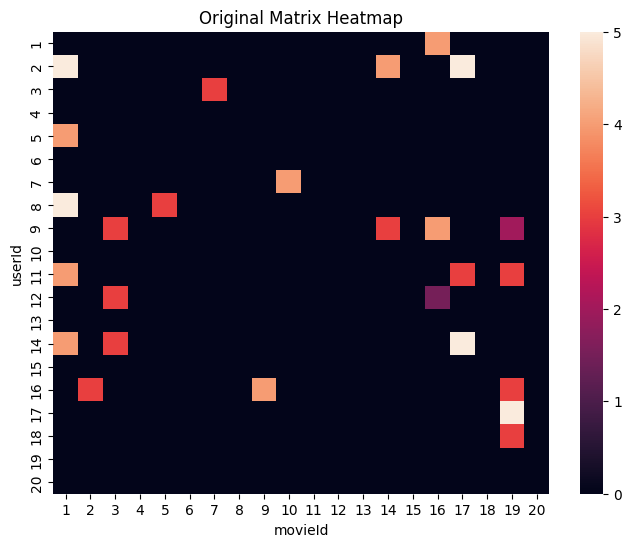

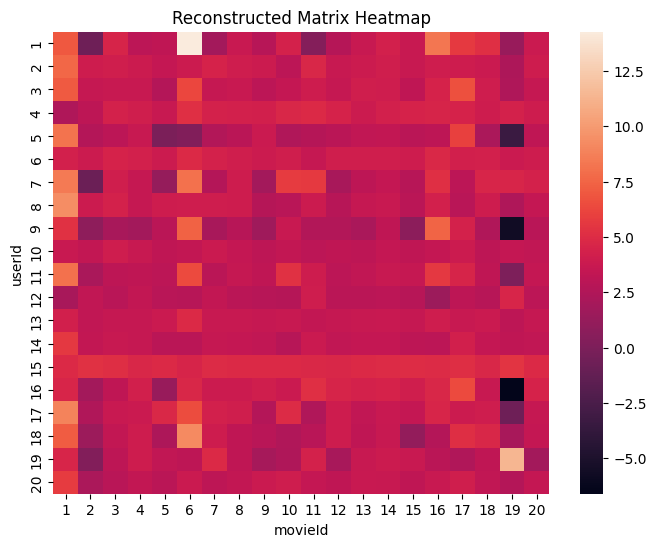

In [17]:
# Heatmap: Original vs Reconstructed

sample_original = matrix_filled.iloc[:20,:20]

sample_reconstructed = \
    reconstructed_df_final.iloc[:20,:20]

plt.figure(figsize=(8,6))

sns.heatmap(sample_original)

plt.title("Original Matrix Heatmap")

plt.show()

plt.figure(figsize=(8,6))

sns.heatmap(sample_reconstructed)

plt.title("Reconstructed Matrix Heatmap")

plt.show()

In [18]:
# Step 10: Generate Top-N Recommendations

sample_user = reconstructed_df_final.index[0]

user_ratings = reconstructed_df_final.loc[
    sample_user
]

already_rated = user_item_matrix.loc[
    sample_user
].dropna().index

recommendations = user_ratings.drop(
    already_rated
)

top_n = recommendations.sort_values(
    ascending=False
).head(10)

top_movies = movies[
    movies['movieId'].isin(top_n.index)
]

print("\nTop 10 Recommended Movies for User:",
      sample_user)

print(top_movies[['movieId','title']])


Top 10 Recommended Movies for User: 1
      movieId                                              title
5           6                                        Heat (1995)
258       293  Léon: The Professional (a.k.a. The Professiona...
695       858                              Godfather, The (1972)
956      1193             One Flew Over the Cuckoo's Nest (1975)
959      1197                         Princess Bride, The (1987)
962      1200                                      Aliens (1986)
967      1206                         Clockwork Orange, A (1971)
975      1214                                       Alien (1979)
1050     1291          Indiana Jones and the Last Crusade (1989)
3322     4226                                     Memento (2000)


In [19]:
# Compare Predicted vs Actual Ratings

comparison_df = pd.DataFrame({
    "Actual": actuals[:20],
    "Predicted": preds[:20]
})

print("\nPredicted vs Actual Ratings:")

comparison_df


Predicted vs Actual Ratings:


,Actual,Predicted
0,3.0,3.811323
1,4.0,4.313054
2,4.0,9.726720
3,2.0,2.700446
4,2.0,-3.075258
5,3.0,-5.657693
6,5.0,7.518176
7,2.0,5.383591
8,2.5,-6.790118
9,3.0,5.727163


In [20]:
# Final Evaluation Results

results_df = pd.DataFrame({

    "Latent Factors (k)": k_values,

    "RMSE": rmse_list,

    "MAE": mae_list

})

results_df

,Latent Factors (k),RMSE,MAE
0,5,7.334079,3.638830
1,10,6.973746,3.673452
2,20,6.553129,3.657082
3,50,5.693606,3.367759


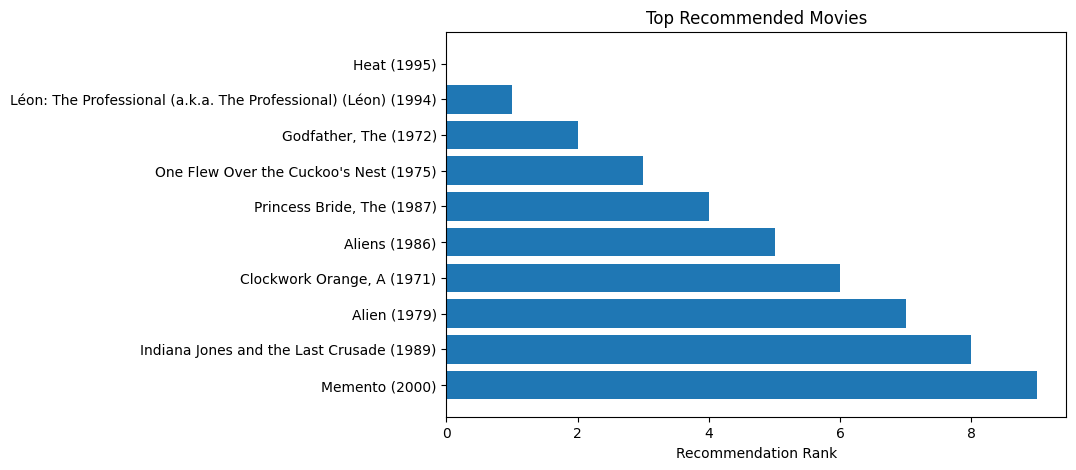

In [21]:
# Visualization: Top Recommended Movies

top_movies_titles = top_movies['title']

plt.figure(figsize=(8,5))

plt.barh(
    top_movies_titles,
    range(len(top_movies_titles))
)

plt.xlabel("Recommendation Rank")

plt.title("Top Recommended Movies")

plt.gca().invert_yaxis()

plt.show()

**SCENARIO 2 – MATRIX FACTORIZATION USING NMF**

Problem Statement
Use Non-negative Matrix Factorization (NMF) to generate recommendations based on latent features.

Dataset (Same / Alternative Dataset)
Same MovieLens Dataset (or any rating dataset)

Target Variable: Predicted ratings / Recommendations
Input Features
• User ID
• Movie ID
• Ratings

IN-LAB TASKS
1.	Load dataset
2.	Create User-Item matrix
3.	Handle missing values (fill with 0 or mean)
4.	Apply NMF model
5.	Factorize into:
a.	User-feature matrix
b.	Item-feature matrix
6.	Reconstruct the rating matrix
7.	Predict missing values
8.	Generate Top-N recommendations

Evaluation Metrics
• RMSE
• Precision@K
• Recall@K

Analysis Tasks
• Compare SVD vs NMF performance
• Observe interpretability of NMF factors
• Analyze sparsity handling
• Compare recommendation diversity

Visualization
• Latent feature visualization
• Reconstruction comparison
• Recommendation ranking chart


In [22]:
# Step 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split



In [23]:
# Step 2: Upload ratings.csv and movies.csv
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)


Ratings Shape: (105339, 4)
Movies Shape: (10329, 3)


In [24]:

ratings.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [25]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [26]:
# Step 3: Create User-Item Matrix

ratings = ratings[['userId','movieId','rating']]

train_data, test_data = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

user_item_matrix = train_data.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

print("Matrix Shape:", user_item_matrix.shape)

Matrix Shape: (668, 9588)


In [27]:
# Step 4: Handle Missing Values

matrix_filled = user_item_matrix.fillna(0)

matrix_filled.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,143882,144656,144976,146344,146656,146684,146878,148238,148626,149532
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# Step 5: Apply NMF

n_components = 20   # latent features

nmf_model = NMF(
    n_components=n_components,
    init='random',
    random_state=42,
    max_iter=200
)

# Factorization
user_features = nmf_model.fit_transform(
    matrix_filled
)

item_features = nmf_model.components_

print("User Feature Matrix Shape:",
      user_features.shape)

print("Item Feature Matrix Shape:",
      item_features.shape)

User Feature Matrix Shape: (668, 20)
Item Feature Matrix Shape: (20, 9588)


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [29]:
# Step 5: Apply NMF

n_components = 20   # latent features

nmf_model = NMF(
    n_components=n_components,
    init='random',
    random_state=42,
    max_iter=200
)

# Factorization
user_features = nmf_model.fit_transform(
    matrix_filled
)

item_features = nmf_model.components_

print("User Feature Matrix Shape:",
      user_features.shape)

print("Item Feature Matrix Shape:",
      item_features.shape)

User Feature Matrix Shape: (668, 20)
Item Feature Matrix Shape: (20, 9588)


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [30]:
# Step 6: Reconstruct Matrix

reconstructed_matrix = np.dot(
    user_features,
    item_features
)

reconstructed_df = pd.DataFrame(
    reconstructed_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

reconstructed_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,143882,144656,144976,146344,146656,146684,146878,148238,148626,149532
userId,,,,,,,,,,,,,,,,,,,,,
1,1.817785,0.487703,0.264959,0.021710,0.198009,0.731845,0.177487,0.032309,0.112848,0.978714,...,0.0,0.0,0.0,0.0,0.000000,0.028024,0.017515,0.0,0.000244,0.0
2,1.842656,0.185936,1.225524,0.024679,1.092423,1.706158,0.909716,0.080099,0.489073,0.019619,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
3,0.495293,0.554469,0.252935,0.062461,0.118558,0.473361,0.130652,0.055944,0.083535,1.634398,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
4,0.180986,0.080759,0.000707,0.103294,0.072369,0.151273,0.051959,0.001359,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
5,0.522790,0.149727,0.095166,0.004624,0.099891,0.177929,0.135009,0.012029,0.034351,0.159107,...,0.0,0.0,0.0,0.0,0.019032,0.001596,0.000997,0.0,0.005962,0.0


In [31]:
# Step 7: Predict Missing Ratings

preds = []
actuals = []

for row in test_data.itertuples():

    user = row.userId
    movie = row.movieId

    if user in reconstructed_df.index \
       and movie in reconstructed_df.columns:

        pred = reconstructed_df.loc[user, movie]

        preds.append(pred)

        actuals.append(row.rating)

# Calculate RMSE

rmse = np.sqrt(
    mean_squared_error(actuals, preds)
)

print("RMSE:", rmse)

RMSE: 3.0763491846080604


In [32]:
# Step 8: Precision@K and Recall@K

def precision_recall_at_k(
        reconstructed_df,
        user_item_matrix,
        k=10,
        threshold=3.5):

    precisions = []
    recalls = []

    for user in reconstructed_df.index:

        user_true = user_item_matrix.loc[user]

        user_pred = reconstructed_df.loc[user]

        already_rated = user_true.dropna().index

        recommendations = user_pred.drop(
            already_rated
        )

        top_k = recommendations.sort_values(
            ascending=False
        ).head(k)

        relevant_items = user_true[
            user_true >= threshold
        ].index

        recommended_items = top_k.index

        true_positives = len(
            set(recommended_items)
            &
            set(relevant_items)
        )

        precision = true_positives / k

        recall = true_positives / \
            max(len(relevant_items),1)

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), \
           np.mean(recalls)


precision_k, recall_k = \
    precision_recall_at_k(
        reconstructed_df,
        user_item_matrix,
        k=10
    )

print("Precision@10:", precision_k)
print("Recall@10   :", recall_k)

Precision@10: 0.0
Recall@10   : 0.0


In [33]:
# Step 9: Top-N Recommendations

sample_user = reconstructed_df.index[0]

user_ratings = reconstructed_df.loc[
    sample_user
]

already_rated = user_item_matrix.loc[
    sample_user
].dropna().index

recommendations = user_ratings.drop(
    already_rated
)

top_n = recommendations.sort_values(
    ascending=False
).head(10)

top_movies = movies[
    movies['movieId'].isin(top_n.index)
]

print("\nTop 10 Recommended Movies:")

print(top_movies[['movieId','title']])


Top 10 Recommended Movies:
      movieId                                              title
0           1                                   Toy Story (1995)
258       293  Léon: The Professional (a.k.a. The Professiona...
471       527                            Schindler's List (1993)
522       589                  Terminator 2: Judgment Day (1991)
695       858                              Godfather, The (1972)
975      1214                                       Alien (1979)
999      1240                             Terminator, The (1984)
1029     1270                          Back to the Future (1985)
7669    58559                            Dark Knight, The (2008)
8629    79132                                   Inception (2010)


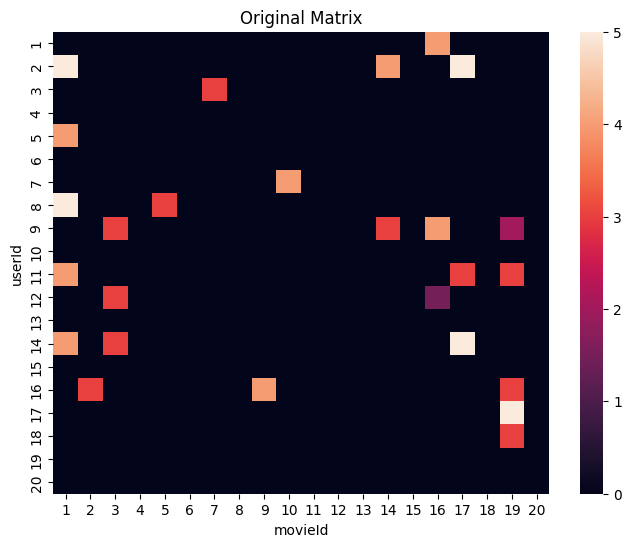

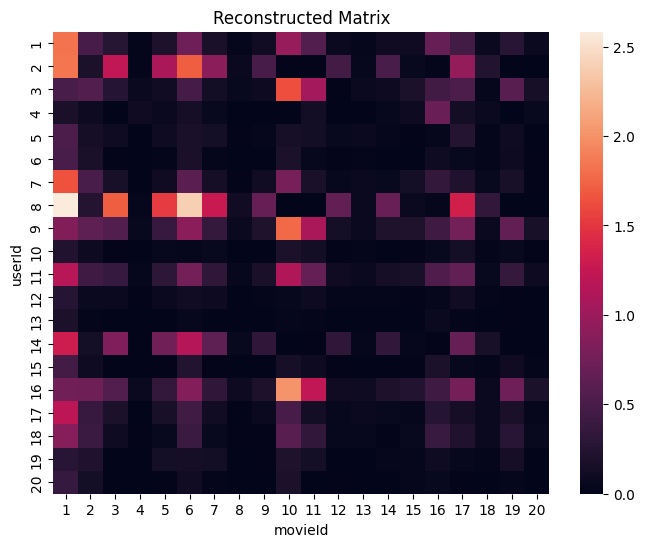

In [34]:
# Visualization 2: Reconstruction Comparison

sample_original = matrix_filled.iloc[:20,:20]

sample_reconstructed = \
    reconstructed_df.iloc[:20,:20]

plt.figure(figsize=(8,6))

sns.heatmap(sample_original)

plt.title("Original Matrix")

plt.show()

plt.figure(figsize=(8,6))

sns.heatmap(sample_reconstructed)

plt.title("Reconstructed Matrix")

plt.show()

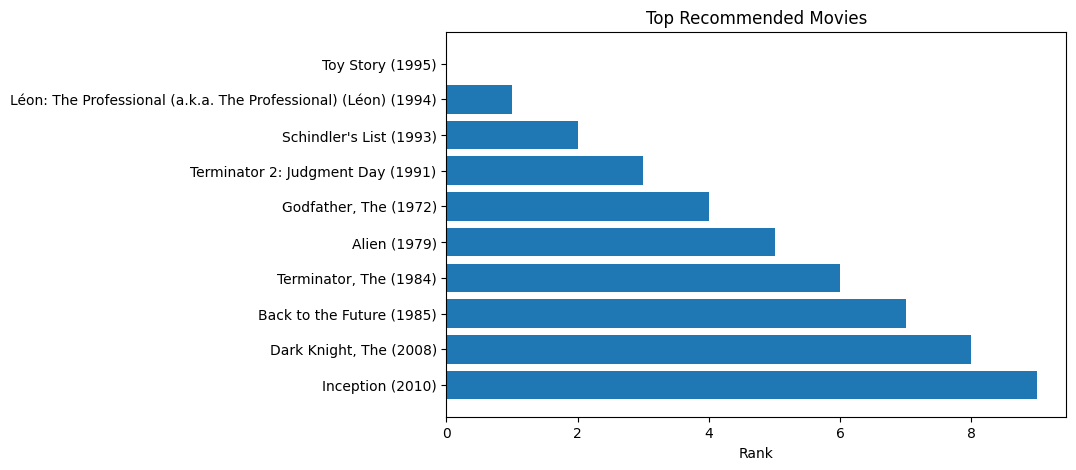

In [35]:
# Visualization 3: Recommendation Ranking

titles = top_movies['title']

plt.figure(figsize=(8,5))

plt.barh(
    titles,
    range(len(titles))
)

plt.xlabel("Rank")

plt.title("Top Recommended Movies")

plt.gca().invert_yaxis()

plt.show()